# Movie Recommendation System (Content-Based Filtering)

Recommends movies similar to a given title by comparing genres and plot descriptions using TF-IDF and cosine similarity - the same core technique behind many real-world "because you watched..." recommendation features.

**Note on the data:** this notebook uses a synthetically generated movie metadata dataset (`data/movies.csv`, 150 movies) so it runs fully offline. Swap in a real dataset (e.g. MovieLens or TMDB) to use with real titles.

In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

%matplotlib inline

## 1. Load and explore the data

In [2]:
df = pd.read_csv("data/movies.csv")
print(f"Loaded {len(df)} movies")
df.head()

Loaded 150 movies


,title,genres,description,director,year
0,Edge of Storm,Crime|Action|Adventure,A story about an undercover agent infiltrates ...,C. Petrov,1996
1,The Last Fury,Adventure,A story about a treasure hunt through uncharte...,R. Nakamura,1997
2,Shadows of Silence,Action|Animation|Adventure,A story about a relentless chase across the ci...,C. Petrov,1996
3,Echoes of Paradox,Action|Drama|Horror,A story about a lone hero fighting overwhelmin...,R. Nakamura,1999
4,The Last Empire,Fantasy|Crime,A story about a young hero discovers magical p...,C. Petrov,2013


## 2. Combine genres + description into a single text feature

In [3]:
# Genres are repeated to weight them more heavily than the free-text description,
# since shared genre is the strongest similarity signal for this dataset.
df["combined_features"] = (
    (df["genres"].str.replace("|", " ", regex=False) + " ") * 2 + df["description"]
)
df[["title", "combined_features"]].head(3)

,title,combined_features
0,Edge of Storm,Crime Action Adventure Crime Action Adventure ...
1,The Last Fury,Adventure Adventure A story about a treasure h...
2,Shadows of Silence,Action Animation Adventure Action Animation Ad...


## 3. TF-IDF vectorization

In [4]:
vectorizer = TfidfVectorizer(stop_words="english")
tfidf_matrix = vectorizer.fit_transform(df["combined_features"])
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

TF-IDF matrix shape: (150, 155)


## 4. Compute cosine similarity between all movies

In [5]:
similarity_matrix = cosine_similarity(tfidf_matrix)
title_to_index = pd.Series(df.index, index=df["title"]).drop_duplicates()

def recommend(title, top_n=5):
    if title not in title_to_index:
        print(f"'{title}' not found in dataset.")
        return pd.DataFrame()
    idx = title_to_index[title]
    scores = list(enumerate(similarity_matrix[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)
    top_matches = scores[1: top_n + 1]
    movie_indices = [i for i, _ in top_matches]
    similarity_scores = [round(s, 3) for _, s in top_matches]
    result = df.iloc[movie_indices][["title", "genres", "year"]].copy()
    result["similarity"] = similarity_scores
    return result.reset_index(drop=True)

## 5. Try it out

In [6]:
sample_title = df["title"].sample(1, random_state=42).iloc[0]
original = df[df["title"] == sample_title].iloc[0]
print(f"Because you watched: '{sample_title}' ({original['genres']}, {original['year']})\n")
recommend(sample_title, top_n=5)

Because you watched: 'Into the Horizon' (Action|Mystery|Comedy, 2016)



,title,genres,year,similarity
0,The Horizon,Mystery|Comedy,2006,0.819
1,Shadows of Sanctuary,Action,2009,0.578
2,Legacy of Ashes,Action,1997,0.578
3,The Last Dream,Comedy|Action|Mystery,1997,0.567
4,Into the Requiem,Action|Comedy,2002,0.556


## 6. Visualize recommendation scores

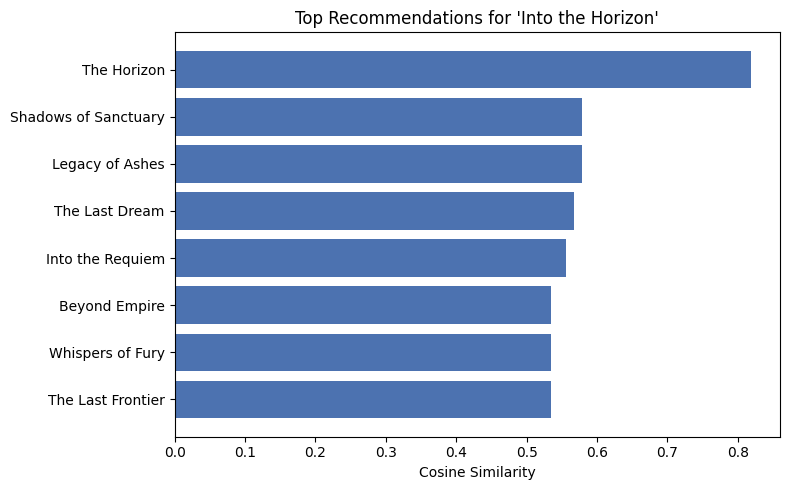

In [7]:
recs = recommend(sample_title, top_n=8)
plt.figure(figsize=(8, 5))
plt.barh(recs["title"], recs["similarity"], color="#4C72B0")
plt.xlabel("Cosine Similarity")
plt.title(f"Top Recommendations for '{sample_title}'")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Genre distribution in the dataset

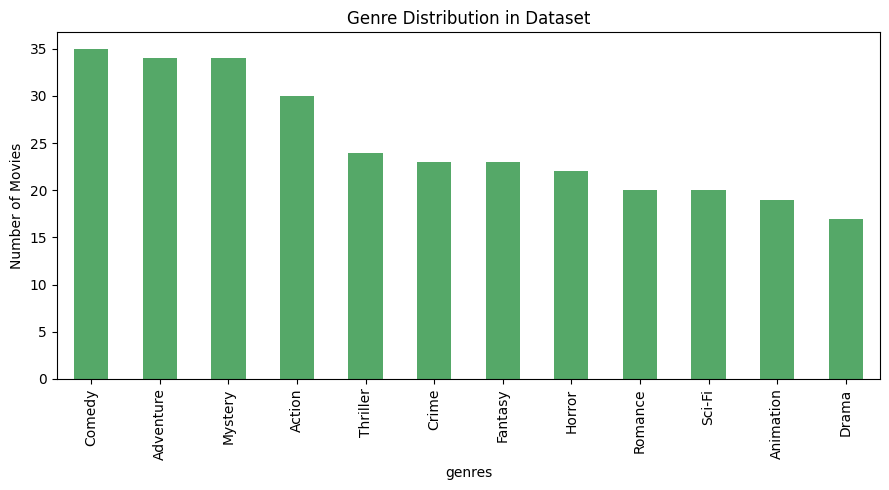

In [8]:
all_genres = df["genres"].str.split("|").explode()
genre_counts = all_genres.value_counts()

plt.figure(figsize=(9, 5))
genre_counts.plot(kind="bar", color="#55A868")
plt.title("Genre Distribution in Dataset")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()

## 8. Try your own title

In [9]:
# Pick any title from df["title"].tolist() and try it here
recommend(df["title"].iloc[0], top_n=5)

,title,genres,year,similarity
0,The Last Horizon,Crime|Adventure,2006,0.850
1,The Last Ashes,Crime,2016,0.655
2,Rise of Horizon,Crime,2014,0.655
3,The Last Fury,Adventure,1997,0.546
4,Legacy of Odyssey,Adventure,2014,0.546
